In [ ]:
import torch
from torch import nn

import math
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

In [ ]:
torch.manual_seed(111)

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

In [ ]:
device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [ ]:
train_set = torchvision.datasets.MNIST(
    root = ".", train=True, download = True, transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


In [ ]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

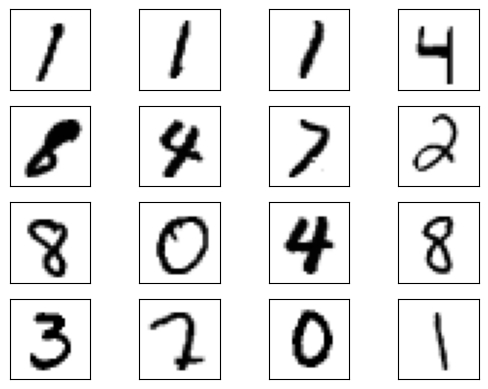

In [ ]:
real_samples, mnist_labels = next(iter(train_loader))
for i in range(16):
  ax = plt.subplot(4, 4, i + 1)
  plt.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
  plt.xticks([])
  plt.yticks([])

# ***Discriminator***

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            # Sigmoid removed because we will use BCEWithLogitsLoss
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output

In [ ]:
discriminator = Discriminator().to(device=device)

# ***Generator***

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output

In [ ]:
generator = Generator().to(device=device)

model training

In [ ]:
lr = 0.0001
num_epochs = 200
# Switched to BCEWithLogitsLoss for compatibility with autocast
loss_function = nn.BCEWithLogitsLoss()

discriminator = Discriminator().to(device=device)
generator = Generator().to(device=device)

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Using the modern torch.amp API
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        real_samples = real_samples.to(device=device)
        batch_size_current = real_samples.size(0)
        real_samples_labels = torch.ones((batch_size_current, 1)).to(device=device)
        generated_samples_labels = torch.zeros((batch_size_current, 1)).to(device=device)

        latent_space_samples = torch.randn((batch_size_current, 100)).to(device=device)

        # Training the discriminator
        optimizer_discriminator.zero_grad()
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            generated_samples = generator(latent_space_samples)
            # We separate the loss calculation to ensure the discriminator sees both
            output_real = discriminator(real_samples)
            loss_real = loss_function(output_real, real_samples_labels)

            output_fake = discriminator(generated_samples.detach())
            loss_fake = loss_function(output_fake, generated_samples_labels)

            loss_discriminator = (loss_real + loss_fake) / 2

        if scaler:
            scaler.scale(loss_discriminator).backward()
            scaler.step(optimizer_discriminator)
        else:
            loss_discriminator.backward()
            optimizer_discriminator.step()

        # Training the generator
        optimizer_generator.zero_grad()
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            # Generator wants discriminator to think these are real
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)

        if scaler:
            scaler.scale(loss_generator).backward()
            scaler.step(optimizer_generator)
            scaler.update()
        else:
            loss_generator.backward()
            optimizer_generator.step()

        if n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator.item():.4f} Loss G.: {loss_generator.item():.4f}")

Epoch: 0 Loss D.: 0.0516 Loss G.: 5.0717
Epoch: 1 Loss D.: 0.0153 Loss G.: 4.5267
Epoch: 2 Loss D.: 0.0047 Loss G.: 7.6564
Epoch: 3 Loss D.: 0.0742 Loss G.: 3.6605
Epoch: 4 Loss D.: 0.1752 Loss G.: 4.2191
Epoch: 5 Loss D.: 0.1074 Loss G.: 4.2764
Epoch: 6 Loss D.: 0.1065 Loss G.: 3.5093
Epoch: 7 Loss D.: 0.3967 Loss G.: 3.1158
Epoch: 8 Loss D.: 0.4645 Loss G.: 2.2677
Epoch: 9 Loss D.: 0.3726 Loss G.: 1.7715
Epoch: 10 Loss D.: 0.3722 Loss G.: 1.6735
Epoch: 11 Loss D.: 0.3946 Loss G.: 1.6067
Epoch: 12 Loss D.: 0.4797 Loss G.: 1.7346
Epoch: 13 Loss D.: 0.4852 Loss G.: 1.4803
Epoch: 14 Loss D.: 0.4851 Loss G.: 1.3441
Epoch: 15 Loss D.: 0.5456 Loss G.: 1.1636
Epoch: 16 Loss D.: 0.5693 Loss G.: 1.1818
Epoch: 17 Loss D.: 0.4848 Loss G.: 1.5146
Epoch: 18 Loss D.: 0.4511 Loss G.: 1.3204
Epoch: 19 Loss D.: 0.5639 Loss G.: 0.9591
Epoch: 20 Loss D.: 0.5596 Loss G.: 0.9448
Epoch: 21 Loss D.: 0.4900 Loss G.: 1.0288
Epoch: 22 Loss D.: 0.5527 Loss G.: 1.1235
Epoch: 23 Loss D.: 0.5090 Loss G.: 1.3212
Ep

In [30]:
print(f"Using device: {device}")
if torch.cuda.is_available():
    print("GPU is available. You can check its utilization using !nvidia-smi in a new cell.")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Training will proceed on CPU, which will be slower.")

Using device: cuda
GPU is available. You can check its utilization using !nvidia-smi in a new cell.
Tesla T4


In [31]:
# Run this cell to check GPU utilization (if a GPU is connected)
!nvidia-smi

Tue Apr 14 11:30:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             34W /   70W |     281MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
latent_space_samples = torch.randn(batch_size, 100).to(device=device)
generated_samples = generator(latent_space_samples)

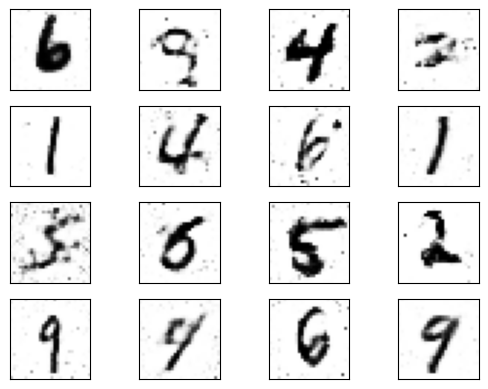

In [33]:
generated_samples = generated_samples.cpu().detach()
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

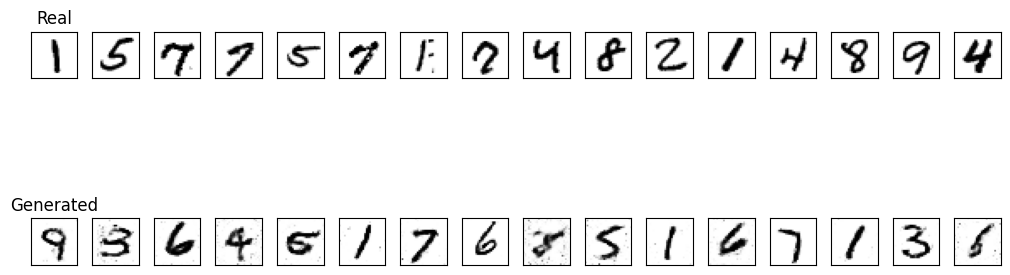

In [37]:
import matplotlib.pyplot as plt

# Get a new batch of real samples
real_samples, _ = next(iter(train_loader))
real_samples = real_samples.to(device=device)

# Generate a new batch of fake samples
latent_space_samples = torch.randn(batch_size, 100).to(device=device)
generated_samples = generator(latent_space_samples)

# Move to CPU and detach for plotting
real_samples = real_samples.cpu().detach()
generated_samples = generated_samples.cpu().detach()


plt.figure(figsize=(10, 5))
for i in range(16):
    # Display real samples
    ax = plt.subplot(2, 16, i + 1)
    plt.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])
    if i == 0:
        ax.set_title("Real")

    # Display generated samples
    ax = plt.subplot(2, 16, i + 16 + 1)
    plt.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])
    if i == 0:
        ax.set_title("Generated")

plt.tight_layout()
plt.show()